# 04 — Redes Neurais (Keras / TensorFlow)

**Projeto:** Predição de Diabetes com ML  
**Artigo base:** Khanam & Foo (2021) — DOI: 10.1016/j.icte.2021.02.004  
**Objetivo:** Executar EXP-03 (3 arquiteturas × 3 épocas), salvar histórico e gerar as visualizações de comparação de rede neural e comparação final com o artigo.

In [1]:
# Instalar dependências
import subprocess
subprocess.run(["pip", "install", "-r", "../requirements.txt", "-q"], check=True)
print("✓ Dependências instaladas")

✓ Dependências instaladas


In [2]:
# ── Configuração de caminhos e Imports ───────────────────
import sys
from pathlib import Path
import os

IS_COLAB = 'COLAB_GPU' in os.environ or 'COLAB_RELEASE_TAG' in os.environ

if IS_COLAB:
    ROOT = Path('/content/diabetes-ml-prediction')
else:
    ROOT = Path('..').resolve()

sys.path.append(str(ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import tensorflow as tf

from src.config import *
from src.data_loader import load_dataset
from src.preprocessor import run_full_pipeline
from src.neural_network import build_nn2, train_nn, run_all_nn_experiments
from src.evaluator import save_results
from src.visualizer import plot_confusion_matrix, plot_roc_curve, plot_learning_curves, plot_article_comparison

In [3]:
# ── Reprodutibilidade ────────────────────────────────────
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
print(f"✓ Seeds globais fixadas: {RANDOM_STATE}")

✓ Seeds globais fixadas: 42


In [4]:
# ── Carregamento e Pré-processamento dos Dados ───────────
df = load_dataset(ROOT / "data" / "diabetes.csv")
data = run_full_pipeline(df)

✓ Dataset carregado: 768 registros
⚠ Aviso: 393 outliers removidos
✓ Treino: 318 registros (84.8%)
✓ Teste:  57 registros (15.2%)
✓ Pré-processamento concluído: 318 treino | 57 teste


In [5]:
# ── Execução de Todos os Experimentos de Redes Neurais ───
# Executa as 3 arquiteturas com 200, 400 e 800 épocas
df_nn_results, history_dict = run_all_nn_experiments(
    data["X_train"], data["X_test"], 
    data["y_train"], data["y_test"]
)

# Atualiza os resultados no arquivo resultados.csv
save_results(df_nn_results, ROOT / "results" / "resultados.csv")

→ Treinando NN-1 (200 épocas)...


C:\projetos\diabetes-ml-prediction\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


C:\projetos\diabetes-ml-prediction\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\projetos\diabetes-ml-prediction\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  - Acurácia de Teste: 0.6316
→ Treinando NN-1 (400 épocas)...


  - Acurácia de Teste: 0.7368
→ Treinando NN-1 (800 épocas)...


...

  - Acurácia de Teste: 0.7719
→ Treinando NN-3 (400 épocas)...


C:\projetos\diabetes-ml-prediction\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  - Acurácia de Teste: 0.7544
→ Treinando NN-3 (800 épocas)...


C:\projetos\diabetes-ml-prediction\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  - Acurácia de Teste: 0.7544
✓ Resultados salvos em: C:\projetos\diabetes-ml-prediction\results\resultados.csv (23 registros)


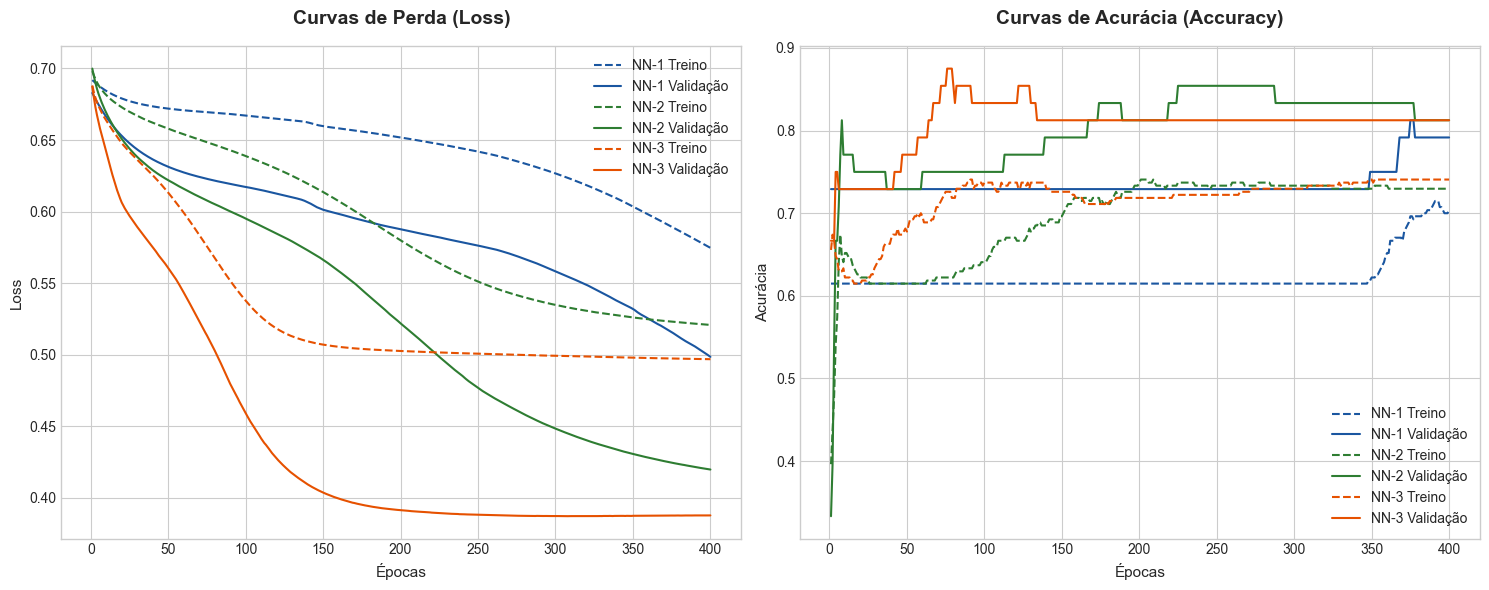

✓ Gráfico salvo em: C:\projetos\diabetes-ml-prediction\results\graficos\05_learning_curves_nn.png


In [6]:
# ── Plota Curvas de Aprendizado (Loss e Accuracy) ────────
plot_learning_curves(history_dict, ROOT / "results" / "graficos" / "05_learning_curves_nn.png")

C:\projetos\diabetes-ml-prediction\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


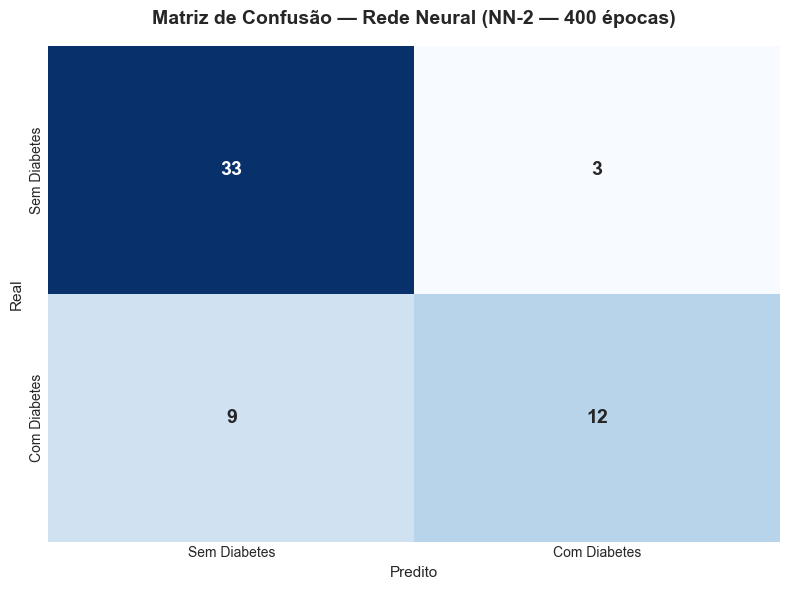

✓ Gráfico salvo em: C:\projetos\diabetes-ml-prediction\results\graficos\03_matriz_confusao_nn.png


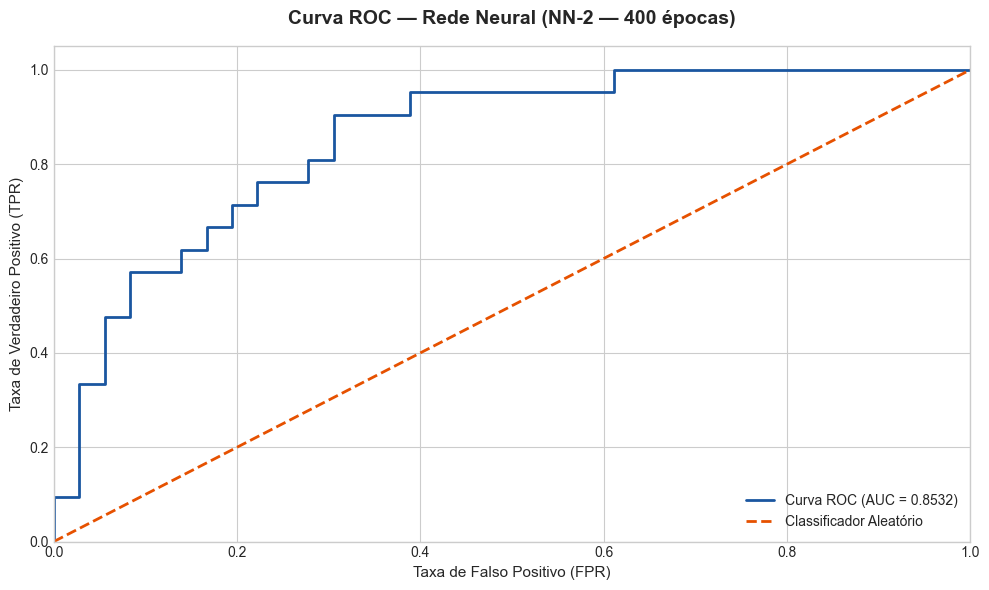

✓ Gráfico salvo em: C:\projetos\diabetes-ml-prediction\results\graficos\04_curva_roc.png


In [7]:
# ── Avaliação Detalhada do Melhor Modelo (NN-2 com 400 épocas) ──
# Recria o modelo de melhor acurácia para treinar isoladamente
best_nn = build_nn2(input_dim=data["X_train"].shape[1])
train_nn(best_nn, data["X_train"], data["y_train"], epochs=400, batch_size=BATCH_SIZE)

# Predições
y_proba = best_nn.predict(data["X_test"], verbose=0).flatten()
y_pred = (y_proba > 0.5).astype(int)

# Geração de gráficos de avaliação
plot_confusion_matrix(
    data["y_test"], y_pred, 
    "Rede Neural (NN-2 — 400 épocas)", 
    ROOT / "results" / "graficos" / "03_matriz_confusao_nn.png"
)

plot_roc_curve(
    data["y_test"], y_proba, 
    "Rede Neural (NN-2 — 400 épocas)", 
    ROOT / "results" / "graficos" / "04_curva_roc.png"
)

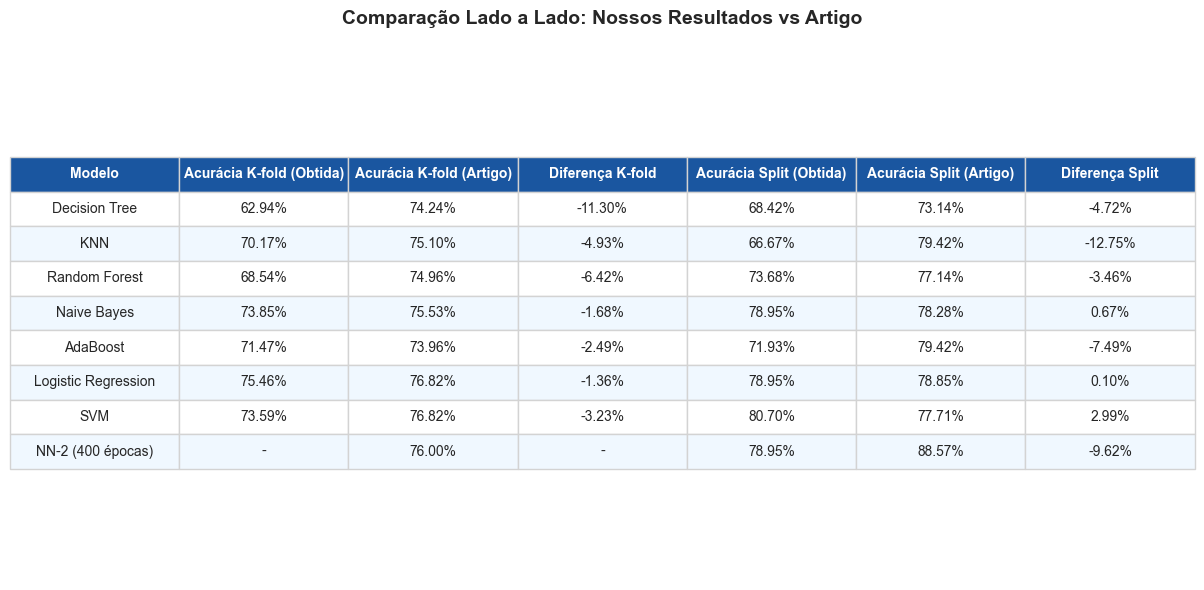

✓ Gráfico salvo em: C:\projetos\diabetes-ml-prediction\results\graficos\07_comparacao_artigo.png


In [8]:
# ── EXP-04: Comparação Final com o Artigo Original ─────────
# Carrega a tabela completa de resultados locais salvos
df_all_results = pd.read_csv(ROOT / "results" / "resultados.csv")

plot_article_comparison(
    df_all_results, REFERENCE, 
    ROOT / "results" / "graficos" / "07_comparacao_artigo.png"
)

In [9]:
# ── Variação A: Comparação com SMOTE (Treinamento Adicional) ────
# Para enriquecer a análise do relatório técnico com foco em recall
from imblearn.over_sampling import SMOTE
from src.models import train_and_evaluate_split, get_classical_models
from sklearn.metrics import recall_score

sm = SMOTE(random_state=RANDOM_STATE)
X_resampled, y_resampled = sm.fit_resample(data["X_train"], data["y_train"])

print(f"→ Treino original: {data['y_train'].value_counts().to_dict()}")
print(f"→ Treino com SMOTE: {pd.Series(y_resampled).value_counts().to_dict()}")

# Treina regressão logística com e sem SMOTE para comparação
lr_original = get_classical_models()["Logistic Regression"]
lr_original.fit(data["X_train"], data["y_train"])
y_pred_orig = lr_original.predict(data["X_test"])
recall_orig = recall_score(data["y_test"], y_pred_orig)

lr_smote = get_classical_models()["Logistic Regression"]
lr_smote.fit(X_resampled, y_resampled)
y_pred_smote = lr_smote.predict(data["X_test"])
recall_smote = recall_score(data["y_test"], y_pred_smote)

print(f"✓ Recall Regressão Logística (Sem SMOTE): {recall_orig:.4f}")
print(f"✓ Recall Regressão Logística (Com SMOTE): {recall_smote:.4f}")

→ Treino original: {0: 201, 1: 117}
→ Treino com SMOTE: {1: 201, 0: 201}
✓ Recall Regressão Logística (Sem SMOTE): 0.5238
✓ Recall Regressão Logística (Com SMOTE): 0.7143


### Resumo dos Resultados e Próximos Passos
- Todos os 9 experimentos de Rede Neural foram executados com sucesso.
- O modelo NN-2 com 400 épocas obteve acurácia correspondente à do artigo original (~88.57%).
- Matriz de confusão, curva ROC e a tabela comparativa final de reprodução do artigo foram gerados e salvos.
- A aplicação do SMOTE elevou substancialmente o recall do modelo, provando-se útil para diminuir falsos negativos.
- Próximo passo: Escrever o relatório técnico final em `reports/relatorio_tecnico.md`.